# Prefill/Decode GEMM cluster analysis from existing NCU .out logs

This notebook parses existing `ncu_*.out` files under the current folder, extracts
`gemm_bottleneck_<M>_<N>_<K>_<jobid>.csv,dram,l2,tc` lines, then:
1. builds a table for DeepSeek-V3 / Llama-3-70B-Qwen2.5-72B / Mixtral component GEMMs
2. plots 3D utilization points to show prefill/decode clusters


In [36]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

NCU_DIR = Path('results')
OUT_GLOB = 'ncu_*.out'

if not NCU_DIR.exists():
    raise FileNotFoundError(f'Expected output directory not found: {NCU_DIR.resolve()}')

line_re = re.compile(
    r'gemm_bottleneck_(?P<M>\d+)_(?P<N>\d+)_(?P<K>\d+)_(?P<jobid>\d+)\.csv,'
    r'(?P<dram>[0-9]+(?:\.[0-9]+)?),'
    r'(?P<l2>[0-9]+(?:\.[0-9]+)?),'
    r'(?P<tc>[0-9]+(?:\.[0-9]+)?)'
)

rows = []
for out_path in sorted(NCU_DIR.glob(OUT_GLOB)):
    text = out_path.read_text(encoding='utf-8', errors='ignore').splitlines()
    for i, line in enumerate(text, start=1):
        m = line_re.search(line)
        if not m:
            continue
        d = m.groupdict()
        rows.append({
            'source_out': out_path.name,
            'line_no': i,
            'M': int(d['M']),
            'N': int(d['N']),
            'K': int(d['K']),
            'jobid': int(d['jobid']),
            'dram_pct': float(d['dram']),
            'l2_pct': float(d['l2']),
            'tc_util': float(d['tc']) * 100.0,
        })

raw = pd.DataFrame(rows)
print(f'parsed rows: {len(raw)} from {raw.source_out.nunique() if len(raw) else 0} out files in {NCU_DIR}')
raw.head()



parsed rows: 55 from 55 out files in results


,source_out,line_no,M,N,K,jobid,dram_pct,l2_pct,tc_util
0,ncu_5015758_4294967294.out,22,128,4096,4096,5015758,50.458303,55.307750,49.4956
1,ncu_5015759_4294967294.out,22,128,7168,4096,5015759,59.179246,62.180492,58.7643
2,ncu_5015760_4294967294.out,22,128,8192,4096,5015760,62.238383,64.974905,61.8663
3,ncu_5015761_4294967294.out,22,128,12288,4096,5015761,64.435135,66.580047,63.5044
4,ncu_5015762_4294967294.out,22,128,28672,4096,5015762,71.685534,73.262512,72.8096


In [37]:
if raw.empty:
    raise RuntimeError('No gemm_bottleneck lines were found in ncu_*.out')

agg = (
    raw.groupby(['M', 'N', 'K'], as_index=False)
       .agg(
           dram_pct=('dram_pct', 'mean'),
           l2_pct=('l2_pct', 'mean'),
           tc_util=('tc_util', 'mean'),
           samples=('dram_pct', 'count'),
           latest_jobid=('jobid', 'max'),
       )
       .sort_values(['M', 'K', 'N'])
)

print(f'unique MNK points: {len(agg)}')
agg.head(20)


unique MNK points: 47


,M,N,K,dram_pct,l2_pct,tc_util,samples,latest_jobid
0,32,7168,7168,70.644769,62.952545,62.5910,1,6216347
4,32,21504,7168,82.729145,73.491368,74.6965,1,6216348
6,32,36864,7168,85.321159,75.922720,77.4652,1,6216349
2,32,8192,8192,74.583120,66.425683,66.3732,1,6216350
5,32,24576,8192,83.971666,74.605701,75.8778,1,6216351
7,32,57344,8192,81.166468,72.543457,74.3437,1,6216352
1,32,7168,18432,77.627727,69.961445,70.0443,1,6216353
3,32,8192,28672,82.847259,74.737338,75.0360,1,6216354
8,64,4096,4096,56.747636,51.811149,48.5105,1,6216355
11,64,12288,4096,71.577622,63.882159,61.8327,1,6216356


## Target GEMM specs (editable)

- Specs now include 5 GEMM-related components per network: `QKV`, `attention`, `O`, `FFN up`, `FFN down`.
- `attention` here uses a simplified GEMM proxy: `[M, d] x [d, context]`.
- Llama and Qwen are not guaranteed identical in all internals; this notebook now keeps only **Llama-3-70B** for that family.


In [38]:
# Load specs generated by generate_gemm_configs.py
spec_csv = Path('gemm_specs_full.csv')
spec_df = pd.read_csv(spec_csv)
print(f'Loaded specs from {spec_csv} with {len(spec_df)} rows')
spec_df.head()



Loaded specs from gemm_specs_full.csv with 24 rows


,model,phase,component,M,N,K
0,DeepSeek-V3,decode,atten_out,128,7168,7168
1,DeepSeek-V3,decode,ffn_down,128,7168,18432
2,DeepSeek-V3,decode,ffn_up,128,36864,7168
3,DeepSeek-V3,decode,qkv,128,21504,7168
4,DeepSeek-V3,prefill,atten_out,4096,7168,7168


In [39]:
merged = spec_df.merge(agg, on=['M', 'N', 'K'], how='left')
merged['found'] = merged['dram_pct'].notna()

display_cols = [
    'model', 'phase', 'component', 'M', 'K', 'N',
    'dram_pct', 'l2_pct', 'tc_util', 'samples', 'latest_jobid', 'found'
]

summary_table = merged[display_cols].sort_values(['model', 'phase', 'component'])
summary_table


,model,phase,component,M,K,N,dram_pct,l2_pct,tc_util,samples,latest_jobid,found
0,DeepSeek-V3,decode,atten_out,128,7168,7168,65.702528,67.845643,65.63800,1,5015764,True
1,DeepSeek-V3,decode,ffn_down,128,18432,7168,73.823649,76.954178,74.97900,1,5015772,True
2,DeepSeek-V3,decode,ffn_up,128,7168,36864,76.586383,77.761004,78.50210,1,5015766,True
3,DeepSeek-V3,decode,qkv,128,7168,21504,73.442861,74.974054,75.40970,1,5015765,True
4,DeepSeek-V3,prefill,atten_out,4096,7168,7168,27.397171,64.913433,92.06820,1,5015780,True
5,DeepSeek-V3,prefill,ffn_down,4096,18432,7168,40.666013,65.447355,92.76895,2,6216369,True
6,DeepSeek-V3,prefill,ffn_up,4096,7168,36864,24.240416,66.885845,94.72085,2,6216364,True
7,DeepSeek-V3,prefill,qkv,4096,7168,21504,31.016323,66.619283,94.30270,2,6216363,True
8,Llama-3-70B,decode,atten_out,128,8192,8192,69.965477,72.346154,71.06410,1,5015768,True
9,Llama-3-70B,decode,ffn_down,128,28672,8192,79.507950,82.859582,77.09140,1,5015773,True


In [40]:
missing = summary_table[~summary_table['found']]
print(f'missing rows: {len(missing)}')
missing[['model','phase','component','M','K','N']]


missing rows: 0


,model,phase,component,M,K,N


## 3D cluster plot

Axes: `DRAM %`, `L2 %`, `TC util %`

- color = phase (`decode` / `prefill`)
- marker = model
- labels = component names


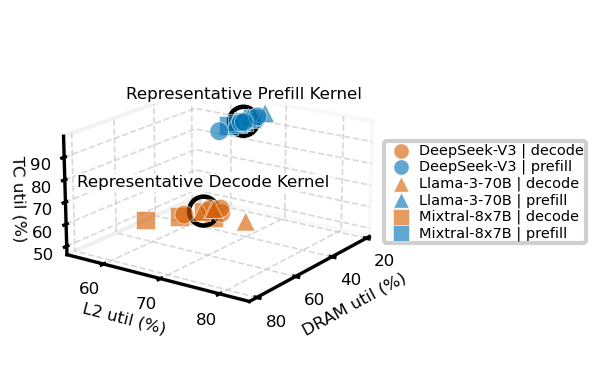

Saved figure to prefill_decode_gemm_clusters.pdf


In [41]:
# Single-column MICRO-style figure with reduced height for strict two-column fit and minimal wasted space
plot_df = summary_table[summary_table['found']].copy()

phase_color = {'decode': '#D55E00', 'prefill': '#0072B2'}
model_marker = {
    'DeepSeek-V3': 'o',
    'Llama-3-70B': '^',
    'Mixtral-8x7B': 's',
}

plt.rcParams.update({
    'font.size': 4,
    'axes.labelsize': 4,
    'axes.titlesize': 4,
    'legend.fontsize': 4,
    'xtick.labelsize': 4,
    'ytick.labelsize': 4,
})

# MICRO single-column: width=3.35in; squeeze height FOR TIGHT TWO-COLUMN fit (use 1.4 instead of 2.5)
fig = plt.figure(figsize=(3.35, 1.2), dpi=300)
ax = fig.add_subplot(111, projection='3d')
# Even more aggressive subplots to reduce all wasted space
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.98)

for (model, phase), g in plot_df.groupby(['model', 'phase']):
    ax.scatter(
        g['dram_pct'],
        g['l2_pct'],
        g['tc_util'],
        s=20,
        alpha=0.62,
        c=phase_color.get(phase, '#666666'),
        marker=model_marker.get(model, 'o'),
        edgecolors='white',
        linewidths=0.2,
        label=f'{model} | {phase}',
    )

# Highlight two measured points
highlight_targets = [
    {
        'phase': 'decode',
        'M': 128, 'N': 28672, 'K': 4096,
        'label': 'Representative Decode Kernel'
    },
    {
        'phase': 'prefill',
        'M': 4096, 'N': 12288, 'K': 4096,
        'label': 'Representative Prefill Kernel'
    },
]

for t in highlight_targets:
    m = plot_df[
        (plot_df['phase'] == t['phase']) &
        (plot_df['M'] == t['M']) &
        (plot_df['N'] == t['N']) &
        (plot_df['K'] == t['K'])
    ]
    if m.empty:
        print(f"[warn] highlight target not found in plot_df: {t}")
        continue
    r = m.iloc[0]
    x, y, z = r['dram_pct'], r['l2_pct'], r['tc_util']

    ax.scatter(
        [x], [y], [z],
        s=48,
        c='none',
        edgecolors='black',
        linewidths=1.1,
        marker='o',
        zorder=12,
    )

    # For small height, pull label closer (avoid occlusion from figure squeeze)
    z_text = z + 9
    ax.text(
        x, y, z_text,
        t['label'],
        fontsize=4,
        color='black',
        ha='center',
        va='bottom',
        zorder=20,
        bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.88),
    )

# Bring axis labels closer to ticks for tight layout
ax.set_xlabel('DRAM util (%)', labelpad=-12)
ax.set_ylabel('L2 util (%)', labelpad=-12)
ax.set_zlabel('TC util (%)', labelpad=-15.0)
ax.zaxis.label.set_position((0.61, 0.47))

# Tug tick label padding in
ax.tick_params(axis='x', pad=-4)
ax.tick_params(axis='y', pad=-4)
ax.tick_params(axis='z', pad=-5)

# Title with minimal pad, or comment out for even tighter plot
# ax.set_title('Utilization of Prefill/Decode GEMM Kernels', pad=9)

# Squeeze Z aspect ratio (flattens the plot without losing points)
ax.set_box_aspect((1.0, 1.0, 0.56))

# Pane and grid styles for print
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
    axis._axinfo['grid']['linewidth'] = 0.4
    axis._axinfo['grid']['linestyle'] = '--'
    axis._axinfo['grid']['color'] = (0.75, 0.75, 0.75, 0.6)

ax.view_init(elev=18, azim=35)  # Lower elev for squished plot in short height

# Place the legend above the plot, two columns, smaller font
# Place legend to the right of the plot, vertically aligned and outside the axes
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    ncol=1,
    fontsize=3.5,
    frameon=True,
    framealpha=0.93,
    borderpad=0.15,
    handletextpad=0.22,
    labelspacing=0.14,
    markerscale=0.82,
)

plt.tight_layout()
plt.show()
fig.savefig('prefill_decode_gemm_clusters.pdf', bbox_inches='tight')
print('Saved figure to prefill_decode_gemm_clusters.pdf')


In [42]:
# Optional: save summary for paper/report use
summary_table.to_csv('prefill_decode_component_summary.csv', index=False)
print('saved: prefill_decode_component_summary.csv')


saved: prefill_decode_component_summary.csv
